In [2]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

iris = load_iris()
dF = pd.DataFrame(data=iris.data, columns = iris.feature_names)
dF.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300,random_state=42)
kmeans.fit(dF);

In [4]:
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


In [5]:
dF['target'] = iris.target
dF['cluster']=kmeans.labels_
iris_result = dF.groupby(['target','cluster'])['sepal length (cm)'].count()
print(iris_result)

target  cluster
0       1          50
1       0           3
        2          47
2       0          36
        2          14
Name: sepal length (cm), dtype: int64


In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(iris.data)

dF['pca_1'] = df_pca[:,0]
dF['pca_2'] = df_pca[:,1]
dF.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster,pca_1,pca_2
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,1,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,1,-2.728717,0.326755


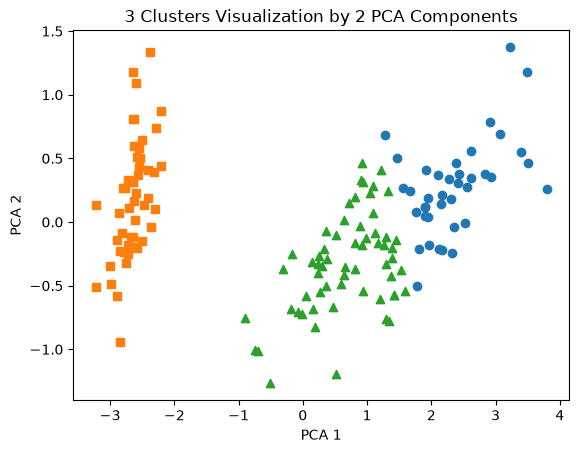

In [7]:
marker0 = dF[dF['cluster']==0].index
marker1 = dF[dF['cluster']==1].index
marker2 = dF[dF['cluster']==2].index

plt.scatter(x=dF.loc[marker0, 'pca_1'], y=dF.loc[marker0, 'pca_2'], marker='o')
plt.scatter(x=dF.loc[marker1, 'pca_1'], y=dF.loc[marker1, 'pca_2'], marker='s')
plt.scatter(x=dF.loc[marker2, 'pca_1'], y=dF.loc[marker2, 'pca_2'], marker='^')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('3 Clusters Visualization by 2 PCA Components')
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.8, random_state=42)
print(X.shape, y.shape)



(200, 2) (200,)


In [9]:
unique, counts = np.unique(y, return_counts=True)
print(unique,counts)

[0 1 2] [67 67 66]


In [10]:
import pandas as pd

df_cls = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
df_cls['target'] = y
df_cls.head()

,ftr1,ftr2,target
0,6.132498,2.352236,1
1,-4.604994,9.671808,0
2,-6.889425,-7.597913,2
3,-8.038095,-8.006081,2
4,-7.351119,-6.200428,2


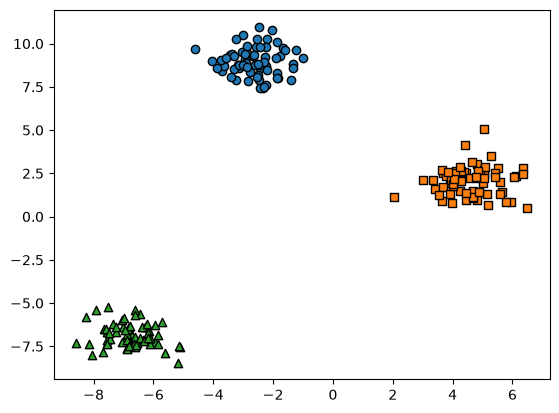

In [11]:
target_list = np.unique(y)

markers=['o', 's', '^', 'P', 'D', 'H', 'x']

for target in target_list:
    target_cluster = df_cls[df_cls['target']==target]
    plt.scatter(x=target_cluster['ftr1'], y=target_cluster['ftr2'], edgecolor='k',
                marker=markers[target] )

plt.show()

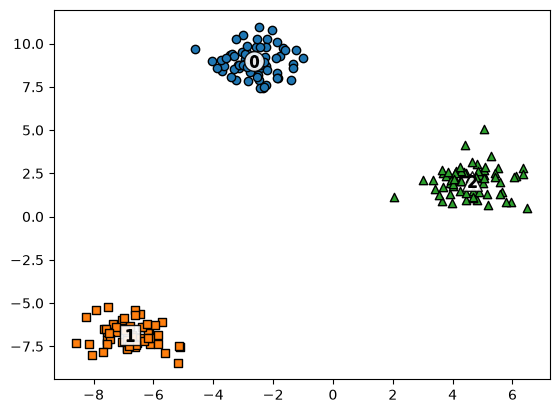

In [12]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=200, random_state=42)
cluster_labels = kmeans.fit_predict(X)
df_cls['kmeans_label']  = cluster_labels

centers = kmeans.cluster_centers_
unique_labels = np.unique(cluster_labels)

markers=['o', 's', '^', 'P','D','H','x']


for label in unique_labels:
    label_cluster = df_cls[df_cls['kmeans_label']==label]
    center = centers[label]
    plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k', 
                marker=markers[label] )
    plt.scatter(x=center[0], y=center[1], s=200, color='white',
                alpha=0.9, edgecolor='k', marker=markers[label])
    plt.scatter(x=center[0], y=center[1], s=70, color='k', edgecolor='k', 
                marker='$%d$' % label)

plt.show()

In [13]:
print(df_cls.groupby('target')['kmeans_label'].value_counts())

target  kmeans_label
0       0               67
1       2               67
2       1               66
Name: count, dtype: int64


In [14]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift

X, y = make_blobs(n_samples=200, n_features=2, centers=3, 
                  cluster_std=0.7, random_state=42)

meanshift= MeanShift(bandwidth=0.8)
cluster_labels = meanshift.fit_predict(X)
print(np.unique(cluster_labels))

[0 1 2 3 4 5 6 7]


In [15]:
meanshift= MeanShift(bandwidth=1.0)
cluster_labels = meanshift.fit_predict(X)
print(np.unique(cluster_labels))

[0 1 2 3 4]


In [16]:
from sklearn.cluster import estimate_bandwidth

bandwidth = estimate_bandwidth(X)
print(round(bandwidth,3))

1.877


In [ ]:
import pandas as pd


df = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
df['target'] = y

best_bandwidth = estimate_bandwidth(X)

meanshift= MeanShift(bandwidth=best_bandwidth)
cluster_labels = meanshift.fit_predict(X)
print(np.unique(cluster_labels))  

[0 1 2]


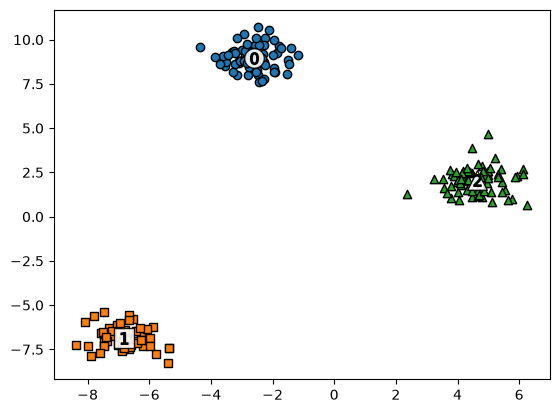

In [ ]:
import matplotlib.pyplot as plt

df['meanshift_label']  = cluster_labels
centers = meanshift.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers=['o', 's', '^', 'x', '*']

for label in unique_labels:
    label_cluster = df[df['meanshift_label']==label]
    center = centers[label]
    plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k', 
                marker=markers[label] )
    plt.scatter(x=center[0], y=center[1], s=200, color='white',
                alpha=0.9, edgecolor='k', marker=markers[label])
    plt.scatter(x=center[0], y=center[1], s=70, color='k', edgecolor='k', 
                marker='$%d$' % label)
    
plt.show()

In [21]:
print(df.groupby('target')['meanshift_label'].value_counts())

target  meanshift_label
0       0                  67
1       2                  67
2       1                  66
Name: count, dtype: int64
